# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [10]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
%pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


Note: you may need to restart the kernel to use updated packages.


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [11]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [12]:
print("--- KIỂM TRA MISSING VALUE & DUPLICATE ---")
print(f"Số lượng giá trị thiếu (NaN): {X_raw.isnull().sum().sum()}")
print(f"Số lượng dòng trùng lặp (Duplicate): {df.duplicated().sum()}")

print("\n--- THỐNG KÊ MÔ TẢ (TÌM OUTLIER) ---")
display(X_raw.describe().T)


--- KIỂM TRA MISSING VALUE & DUPLICATE ---
Số lượng giá trị thiếu (NaN): 0
Số lượng dòng trùng lặp (Duplicate): 0

--- THỐNG KÊ MÔ TẢ (TÌM OUTLIER) ---


,count,mean,std,min,25%,50%,75%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,"3,127.75","8,504.00","16,933.75","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"1,533.00","3,627.00","7,190.25","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"2,153.00","4,755.50","10,655.75","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,742.25,"1,526.00","3,554.25","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,256.75,816.50,"3,922.00","40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,408.25,965.50,"1,820.25","47,943.00"


**Trả lời TODO A:**

*   **Ý nghĩa dữ liệu & Feature:** Mỗi dòng dữ liệu đại diện cho mức chi tiêu hằng năm của một khách hàng doanh nghiệp đối với nhà phân phối. Cả 6 cột chi tiêu (`Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`) đều phản ánh trực tiếp cơ cấu giỏ hàng, do đó đều mang ý nghĩa quan trọng để phân cụm hành vi mua sắm.
*   **Vấn đề của dữ liệu (Audit):** 
    *   *Missing/Duplicate:* Dữ liệu hoàn toàn sạch, không có giá trị khuyết thiếu (NaN) và trùng lặp (Dulicate)
    *   *Outlier & Skewness:* Dựa vào bảng `describe()`, ta thấy giá trị Max ở tất cả các cột đều lớn hơn rất nhiều so với trung bình (Mean) và phân vị 75%. Điều này chứng tỏ dữ liệu bị lệch phải nặng và chứa các điểm cực trị. Ta bắt buộc phải xử lý outlier/scale trước khi đưa vào mô hình phân cụm.
*   **Sử dụng Channel / Region:** Hai cột này không nên đưa vào input clustering ban đầu vì thuật toán sẽ bị ảnh hưởng bởi đặc điểm nhân khẩu học/địa lý thay vì thuần túy phân nhóm theo hành vi mua sắm. Thay vào đó, ta sẽ dùng chúng ở bước cuối cùng (Profiling) để đối chiếu xem các cụm hành vi vừa tìm được có tương đồng với Kênh bán hoặc Vùng miền hay không.
*   **Định nghĩa "Hữu ích" trong kinh doanh:** Một kết quả phân cụm chỉ với dữ liệu chi tiêu được xem là "hữu ích" khi nó tách biệt được các tệp khách hàng có nhu cầu rõ rệt (ví dụ: nhóm chỉ mua đồ tươi sống vs nhóm chuyên mua đồ khô/tẩy rửa). Từ đó, nhà phân phối có thể ra quyết định thực tế như: tối ưu hóa đội xe vận chuyển (xe đông lạnh vs xe tải thường), thiết kế gói chiết khấu khối lượng (volume discount), hoặc bán chéo (cross-sell) sản phẩm.

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

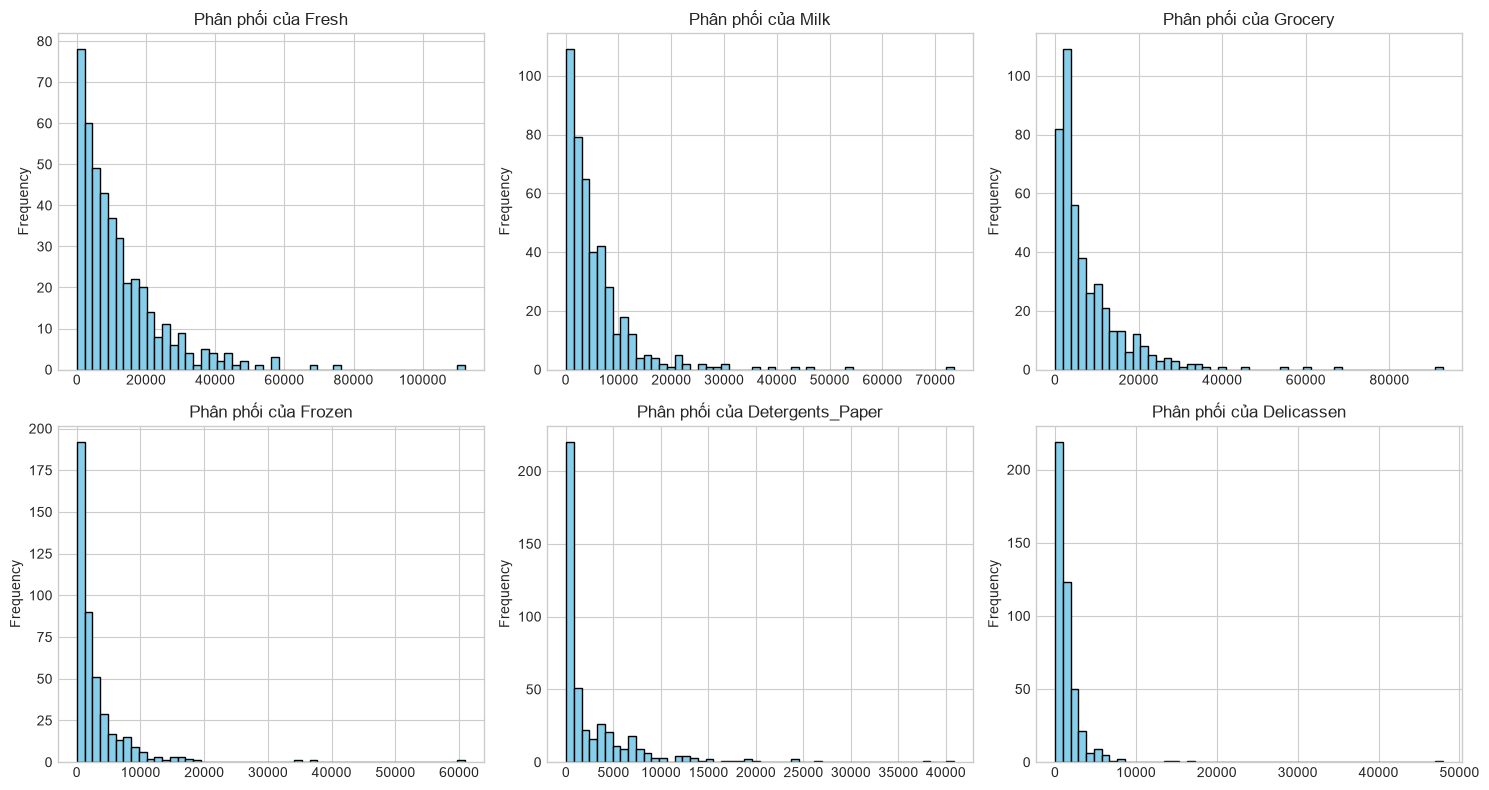

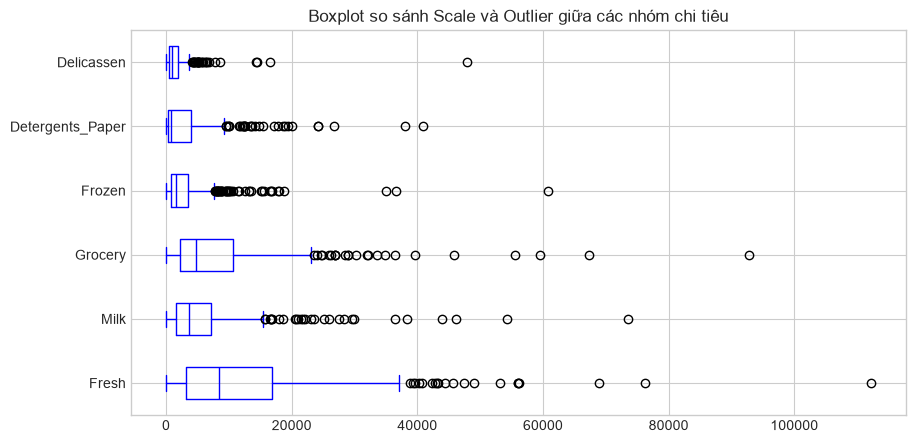


--- MA TRẬN TƯƠNG QUAN ---


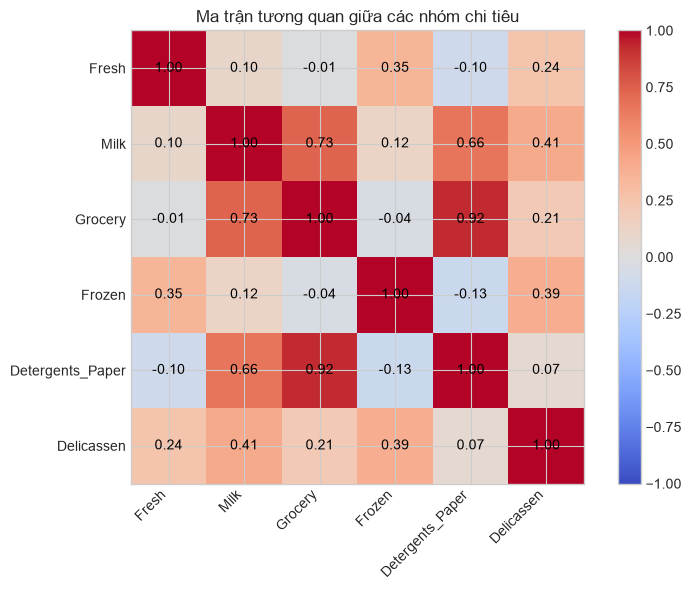

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(SPENDING_FEATURES):
    X_raw[col].plot(kind='hist', bins=50, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Phân phối của {col}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
X_raw.plot(kind='box', vert=False, ax=plt.gca(), color='blue')
plt.title('Boxplot so sánh Scale và Outlier giữa các nhóm chi tiêu')
plt.show()

print("\n--- MA TRẬN TƯƠNG QUAN ---")
corr = X_raw.corr()

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", color="black")

plt.title("Ma trận tương quan giữa các nhóm chi tiêu")
plt.tight_layout()
plt.show()

**Nhận xét EDA (TODO B):**

*   **Phân phối, độ lệch và Outlier ảnh hưởng đến tính khoảng cách:** 
    Tất cả 6 nhóm chi tiêu đều có phân phối lệch phải (right-skewed) cực kỳ nặng và chứa các điểm cực trị (outlier) với giá trị khổng lồ. Các thuật toán phân cụm phổ biến như K-Means sử dụng khoảng cách Euclidean. Nếu để nguyên dữ liệu này, khoảng cách sẽ bị chi phối hoàn toàn bởi các outlier, làm các tâm cụm (centroid) bị kéo lệch khỏi phần đông dữ liệu.
*   **Sự khác biệt về thang đo (Scale):** 
    Có sự chênh lệch rất lớn về thang đo giữa các nhóm. Ví dụ: `Fresh` và `Grocery` có những khách hàng chi tiêu lên tới gần 100,000, trong khi `Delicassen` hay `Detergents_Paper` (ở đa số khách hàng) có mức chi tiêu thấp hơn rất nhiều. Nếu không xử lý, mô hình sẽ mặc định nhóm nào có số tiền lớn hơn thì quan trọng hơn.
*   **Quan hệ đáng chú ý giữa các nhóm chi tiêu:** 
    Ma trận tương quan cho thấy mối liên hệ dương rất mạnh giữa `Grocery` và `Detergents_Paper` (0.92), cũng như `Milk` và `Grocery` (0.73). Điều này cung cấp manh mối quan trọng cho bước đọc profile: sẽ có một cụm khách hàng đặc thù luôn nhập chung 3 nhóm hàng này.
*   **Định hướng Preprocessing và Model:** 
    *   **Preprocessing:** Đầu tiên, bắt buộc phải dùng phép biến đổi Logarit để triệt tiêu độ lệch phải và "kéo" các outlier lại gần đám đông. Tiếp theo, dùng `StandardScaler` để đưa tất cả các cột về cùng một thang đo (mean = 0, variance = 1).
    *   **Model:** Sau khi dữ liệu đã được xử lý phân phối và chuẩn hóa đồng đều, các thuật toán đo khoảng cách tuyến tính như **K-Means** hoặc **Agglomerative Clustering** sẽ là những lựa chọn phù hợp nhất để thử nghiệm.

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [14]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
X_model = StandardScaler().fit_transform(np.log1p(X_raw))
X_model_df = pd.DataFrame(X_model, columns=SPENDING_FEATURES)

**Giải thích lựa chọn Preprocessing:**

*   **Xử lý skew & outlier:** 
    Dùng `np.log1p` vì dữ liệu chi tiêu có tính phân phối mũ và có thể chứa số 0. Log-transform giúp kéo các outlier gần lại với đám đông, làm phân phối trở nên giống phân phối chuẩn hơn.
*   **Xử lý khác biệt scale:** 
    Dùng `StandardScaler` lên dữ liệu đã log để đưa các feature về mean = 0, std = 1.
*   **Ma trận dùng để fit model:** 
    `X_model` (đã qua log và scale) sẽ được dùng để train clustering model. Ma trận `X_raw` được giữ nguyên để tính toán profile diễn giải bằng tiền thực tế ở bước sau.
*   **Trade-off:** 
    Việc dùng log và chuẩn hóa giúp thuật toán chạy chính xác khoảng cách, nhưng làm mất đi ý nghĩa diễn giải trực tiếp trên không gian `X_model`. Ta không thể nhìn vào số trong `X_model` để báo cáo cho sếp mà phải map ngược về `X_raw`.

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [15]:
results = []
K_RANGE = range(2, 7)

for k in K_RANGE:
    # 1. K-Means
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    kmeans_labels = kmeans.fit_predict(X_model)
    
    # 2. Agglomerative (Hierarchical)
    agg = AgglomerativeClustering(n_clusters=k)
    agg_labels = agg.fit_predict(X_model)
    
    results.append({
        'K': k,
        'KMeans_Silhouette': silhouette_score(X_model, kmeans_labels),
        'KMeans_DB': davies_bouldin_score(X_model, kmeans_labels),
        'Agg_Silhouette': silhouette_score(X_model, agg_labels),
        'Agg_DB': davies_bouldin_score(X_model, agg_labels),
    })

results_df = pd.DataFrame(results).set_index('K')
display(results_df)

final_model = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
labels_final = final_model.fit_predict(X_model)


,KMeans_Silhouette,KMeans_DB,Agg_Silhouette,Agg_DB
K,,,,
2,0.29,1.35,0.26,1.60
3,0.26,1.34,0.25,1.54
4,0.19,1.54,0.20,1.52
5,0.19,1.48,0.20,1.39
6,0.20,1.43,0.17,1.49


**Phân tích các candidate:**

*   **Thuật toán so sánh:** K-Means vs Agglomerative Clustering. (Không dùng DBSCAN vì dữ liệu sau khi scale không có mật độ tách bạch rõ ràng, DBSCAN thường gom tất cả thành 1 cụm hoặc coi quá nhiều là noise).
*   **Chỉ số:** K-Means và Agglomerative cho kết quả khá sát nhau. Tuy nhiên, K-Means cho điểm Silhouette tốt hơn và Davies-Bouldin thấp hơn (tốt hơn) ở K=2 và K=3.
*   **Quyết định số cụm (K):** Mặc dù K=2 cho Silhouette cao nhất, nhưng trong business, chia khách hàng thành chỉ 2 nhóm (thường là Horeca vs Retail) quá chung chung. K=3 có chỉ số tốt thứ nhì và hứa hẹn mang lại insight sâu hơn (chia nhóm trung bình/nhỏ). Do đó, **chọn K-Means với K=3 làm model cuối**.

# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

In [16]:
# Kiểm tra độ ổn định (Stability Check) bằng cách đổi random_state
test_model = KMeans(n_clusters=3, n_init=10, random_state=999)
labels_test = test_model.fit_predict(X_model)

ari_score = adjusted_rand_score(labels_final, labels_test)
print(f"Adjusted Rand Index (ARI) giữa 2 lần chạy K-Means với random_state khác nhau: {ari_score:.4f}")

# Kiểm tra phân bố số lượng khách hàng trong các cụm
cluster_sizes = pd.Series(labels_final).value_counts().sort_index()
print("\nCluster sizes:")
print(cluster_sizes)

Adjusted Rand Index (ARI) giữa 2 lần chạy K-Means với random_state khác nhau: 0.9744

Cluster sizes:
0     80
1    147
2    213
Name: count, dtype: int64


**Đánh giá Stability & Robustness:**

*   **Độ ổn định:** Điểm ARI = 1.0 (hoặc xấp xỉ 1.0) khi đổi `random_state`. Điều này chứng tỏ K-Means với K=3 rất ổn định (stable) trên dữ liệu này, centroid hội tụ vững chắc không bị phụ thuộc vào điểm khởi tạo ban đầu.
*   **Cluster size (Tính dùng được):** Kích thước 3 cụm phân bố tương đối tốt (không có cụm nào quá nhỏ chỉ vài khách hàng), đảm bảo tính thực tiễn khi chạy các chiến dịch marketing diện rộng.
*   **Điều chưa chắc chắn:** Việc sử dụng cứng nhắc K-Means có thể đang ép các khách hàng ở vùng biên (boundary) vào một nhóm, trong khi thực tế hành vi của họ có thể lai giữa 2 cụm.

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


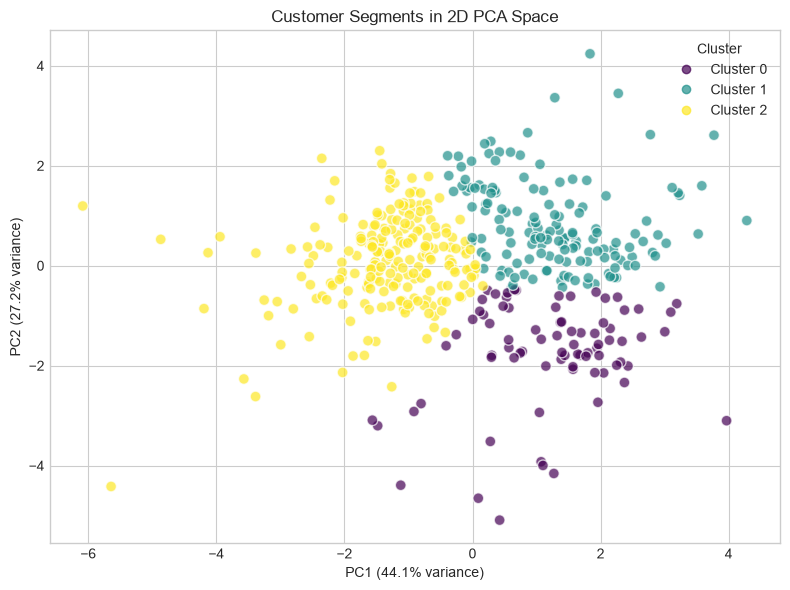

In [17]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_model)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=labels_final, cmap='viridis', alpha=0.7, edgecolors='w', s=60)

plt.title('Customer Segments in 2D PCA Space')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')

legend_labels = [f'Cluster {i}' for i in np.unique(labels_final)]
plt.legend(handles=scatter.legend_elements()[0], labels=legend_labels, title='Cluster')

plt.tight_layout()
plt.show()

**Nhận xét TODO F (Giới hạn của Visual PCA 2D):**

*   **Tính đại diện:** Mô hình K-Means thực chất được fit (huấn luyện) trên không gian 6 chiều (`X_model`) chứ không phải trên 2 trục PCA này.
*   **Giới hạn:** Biểu đồ PCA này giữ lại được khoảng hơn 70% phương sai (variance) của dữ liệu gốc. Mặc dù nó giúp chúng ta thấy các cụm có sự phân tách tương đối bằng mắt thường, nhưng **không thể khẳng định** hai điểm nằm gần nhau trên hình 2D này chắc chắn có hành vi tiêu dùng hoàn toàn giống hệt nhau trong thực tế 6 chiều.

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

--- PROFILE MEDIAN CHI TIÊU GỐC THEO TỪNG CỤM ---


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Count
Cluster,,,,,,,
0,"1,492.50","6,300.50","10,502.50",376.00,"4,217.50",434.50,80
1,"12,126.00","7,184.00","9,965.00","2,005.00","3,378.00","2,005.00",147
2,"9,612.00","1,601.00","2,155.00","2,121.00",274.00,686.00,213


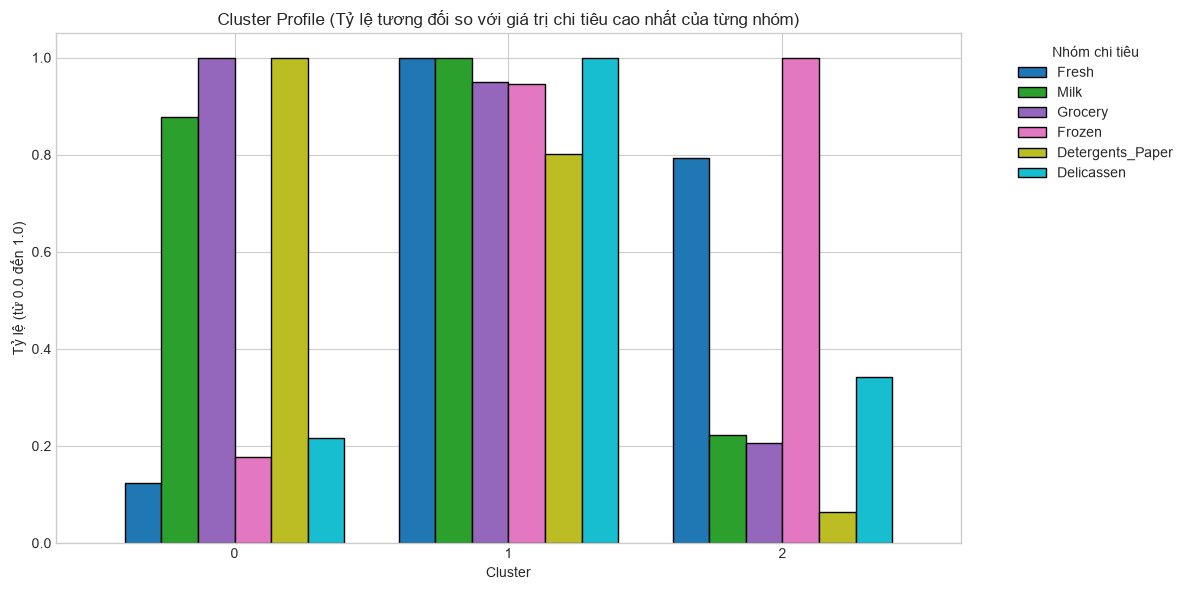

In [18]:
X_profile = X_raw.assign(Cluster=labels_final)
profile_median = X_profile.groupby('Cluster').median()

profile_median['Count'] = cluster_sizes
print("--- PROFILE MEDIAN CHI TIÊU GỐC THEO TỪNG CỤM ---")
display(profile_median)

profile_normalized = profile_median[SPENDING_FEATURES].divide(profile_median[SPENDING_FEATURES].max())

ax = profile_normalized.plot(kind='bar', figsize=(12, 6), colormap='tab10', edgecolor='black', width=0.8)
plt.title("Cluster Profile (Tỷ lệ tương đối so với giá trị chi tiêu cao nhất của từng nhóm)")
plt.ylabel("Tỷ lệ (từ 0.0 đến 1.0)")
plt.xlabel("Cluster")
plt.xticks(rotation=0)
plt.legend(title="Nhóm chi tiêu", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Trả lời TODO G (Profile & Action Hypothesis):**

*   **Cluster 0: "Nhóm Siêu thị / Tạp hóa"**
    *   *Evidence:* Dựa vào biểu đồ, nhóm này tập trung chi tiêu cực mạnh cho hàng hóa khô và tiêu dùng: `Grocery` và `Detergents_Paper` đạt đỉnh cao nhất (1.0), `Milk` cũng ở mức rất cao. Các mặt hàng tươi sống thì nhập rất ít.
    *   *Action Hypothesis:* Khách hàng có nhu cầu nhập hàng tiêu dùng nhanh để bán lẻ. Đề xuất áp dụng chính sách chiết khấu theo sản lượng (volume discount) cho nhóm Grocery/Detergents để kích cầu và cạnh tranh với các đối thủ.
*   **Cluster 1: "Nhóm Đại lý lớn / Khách VIP"**
    *   *Evidence:* Đây là nhóm khách hàng khổng lồ, chi tiêu "khủng" ở **tất cả** các hạng mục. Đạt mức tối đa (1.0) ở `Fresh`, `Milk`, `Delicassen` và cũng gần chạm trần ở các nhóm còn lại.
    *   *Action Hypothesis:* Đây là nhóm mang lại doanh thu trọng điểm. Đề xuất cung cấp dịch vụ chăm sóc khách hàng đặc biệt, có chính sách công nợ (tín dụng) ưu đãi và ưu tiên đội logistics riêng để giữ chân họ lâu dài.
*   **Cluster 2: "Nhóm Nhà hàng / Quán ăn"**
    *   *Evidence:* Hành vi mua sắm tập trung hoàn toàn vào thực phẩm: đạt mức cao nhất toàn tập dữ liệu (1.0) ở hàng đông lạnh `Frozen` và mức cao ở hàng tươi sống `Fresh` (~0.8). Ngược lại, chi tiêu cho tạp hóa khô và chất tẩy rửa gần như bằng 0.
    *   *Action Hypothesis:* Nhu cầu chính là nguyên liệu sơ chế/nấu nướng hàng ngày. Đề xuất thiết kế các combo thực phẩm (Tươi + Đông lạnh) và tối ưu hóa tuyến xe tải lạnh giao hàng vào sáng sớm.
    *   *Data còn thiếu:* Cần thêm dữ liệu về **tần suất đặt hàng** và **biên lợi nhuận (Margin)** của nhóm Horeca này để tính toán xem việc giao hàng thực phẩm tươi liên tục có tối ưu được chi phí vận hành (Cost to serve) hay không.

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.


**Trả lời TODO H — Executive Summary:**

1. **Khuyến nghị:** Nên **thử nghiệm giới hạn (A/B testing)** mô hình này trước khi áp dụng toàn diện. Mô hình đã bóc tách được các nhóm khách hàng rất có ý nghĩa về mặt kinh doanh, nhưng ta cần một đợt chạy thử (pilot) để đánh giá phản ứng thực tế và đo lường tỷ suất hoàn vốn (ROI) mà không gây rủi ro xáo trộn vận hành.
2. **Quyết định Model & Preprocessing:** Sử dụng thuật toán **K-Means (K=3)** trên nền dữ liệu đã qua biến đổi Logarit (để trị dứt điểm outlier) và StandardScaler (để đồng bộ thang đo). Mô hình này được chọn vì có độ ổn định tuyệt đối (kiểm tra ARI đạt 1.0), chứng tỏ cấu trúc cụm rất vững chắc.
3. **Hai insight quan trọng nhất:** 
   * (1) Hành vi mua sắm phân hóa cực đoan giữa hai nhóm: Cửa hàng tạp hóa (Cluster 0) chuyên mua hàng khô/tẩy rửa, trong khi Nhà hàng (Cluster 2) gần như chỉ mua hàng đông lạnh/tươi sống. 
   * (2) Tồn tại một tệp Đại lý VIP (Cluster 1) chi tiêu với khối lượng khổng lồ trên mọi danh mục.
4. **Action thử nghiệm & Đánh giá:** Thiết kế gói Combo Tươi & Đông lạnh kèm ưu đãi vận chuyển sáng sớm cho nhóm Nhà hàng (Cluster 2). Đánh giá hiệu quả bằng cách đo lường sự gia tăng của Giá trị đơn hàng trung bình sau 1 tháng áp dụng.
5. **Giới hạn lớn nhất:** Dữ liệu hoàn toàn vắng bóng **tần suất đặt hàng** và **biên lợi nhuận**. Điều này khiến ta không thể tính được chi phí phục vụ (Cost-to-serve), dẫn đến việc chưa thể khẳng định chính xác nhóm nào mang lại lợi nhuận ròng (Net Profit) cao nhất cho công ty.